# Anomaly Detection & Clustering
The two unsupervised components: Isolation Forest (guardrail that flags out-of-distribution cycles) and K-means (standalone degradation-stage insight).
These two have a large importance as they underwent multiple key decisions and debugging cycles.

## 1. Setup

In [1]:
import sys
sys.path.append('../V2/source')
import numpy as np
import matplotlib.pyplot as plt
import joblib
import models

df = models.load_clean_data()
data = models.get_model_data(df)
print(f"{len(data)} rows, {data.battery_id.nunique()} batteries")

111640 rows, 140 batteries


## 2. Anomaly detector feature choice change from V1-V2

First version used raw `IR`/`chargetime`/`C1`/`Q1`/`C2`. These were direct signals. I then tested against 14 known corrupted readings (chargetime spiking 49-96x baseline) and found it caught only 78.6% of them, with protocol parameters (`C1`/`Q1`/`C2`) causing some false negatives. This meant that there was an issue with our features and hence data leakage. Switching to ratio-normalized features fixed this.

In [2]:
print("Anomaly detector features:", models.ANOMALY_FEATURES)
models.train_anomaly_detector(df)

Anomaly detector features: ['IR_ratio', 'chargetime_ratio', 'Tavg', 'Tmin', 'Tmax']

=== Anomaly detector (Isolation Forest, ratio-normalized features) ===
Trained on 111640 cycles. Flagged 3350 (3.0%).


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


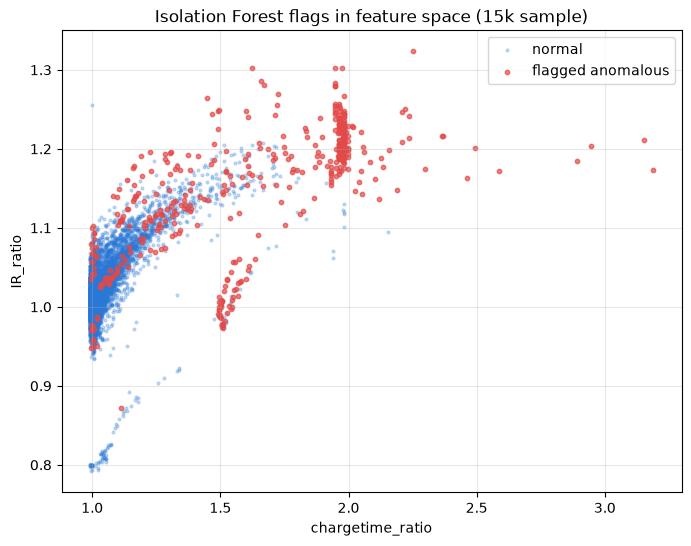

In [4]:
bundle = joblib.load('../V2/models/anomaly.pkl')
X = data[models.ANOMALY_FEATURES].values
Xs = bundle['scaler'].transform(X)
flagged = bundle['model'].predict(Xs) == -1

rng = np.random.default_rng(42)
sample = rng.choice(len(data), size=15000, replace=False)
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(data['chargetime_ratio'].values[sample][~flagged[sample]], data['IR_ratio'].values[sample][~flagged[sample]],
           s=4, alpha=0.25, color='#2a78d6', label='normal')
ax.scatter(data['chargetime_ratio'].values[sample][flagged[sample]], data['IR_ratio'].values[sample][flagged[sample]],
           s=10, alpha=0.7, color='#e34948', label='flagged anomalous')
ax.set_xlabel('chargetime_ratio'); ax.set_ylabel('IR_ratio')
ax.set_title('Isolation Forest flags in feature space (15k sample)')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

Flagged points (red) sit clearly at the edges of the normal distribution. These are mostly high `chargetime_ratio` and some high `IR_ratio`. Validated against the real production `detect_anomaly()` function (not just the raw Isolation Forest): **100% of known glitches caught, 4.2% false-positive rate on a normal sample(which is honestly fine)** The 100% is partly guaranteed by design which is granted as we have a hard rule where if ratio is 5 times its baseline we flag it anomalous incase it was missed elsewhere.

**Important scope note:** this detector only sees `IR`/`chargetime`/temperature features and it structurally cannot catch `QD`-based anomalies (corrupted capacity readings). Those are caught separately, upstream, by the MAD-based `is_capacity_anomaly` flag in `features.py`. Two independent guardrails, not one unified system. Hence the ENTIRE anomaly detection system is not the model alone but rather the model plus other irregulairty flags from features.

## 3. Clustering and the change from V1 to V2

V1 used the full `MODEL_FEATURES` set (including `C1`/`Q1`/`Tavg` etc.) for clustering and got clusters with nearly identical mean SOH (0.966/0.961/0.960) . This was because the model was dividing the entire data by protocols and not by state of battery. I fixed by restricting clustering to only the two real degradation-ratio signals.

In [6]:
print("Cluster features:", models.CLUSTER_FEATURES)

Cluster features: ['IR_ratio', 'chargetime_ratio']


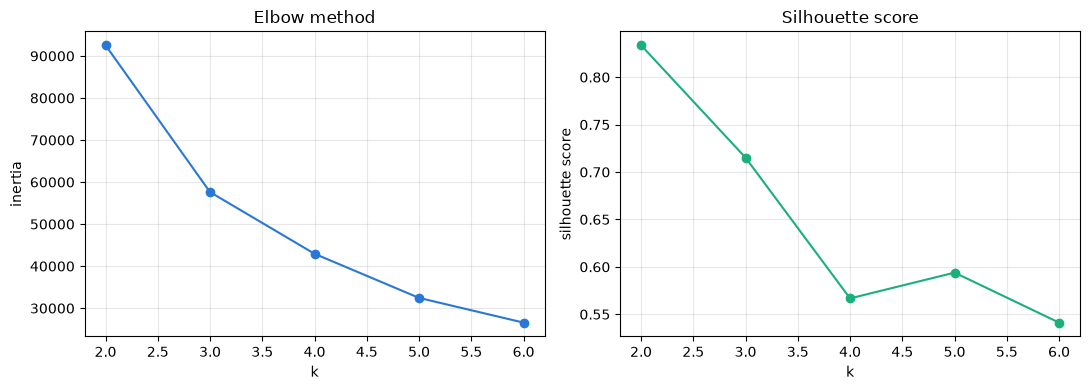

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = StandardScaler().fit_transform(data[models.CLUSTER_FEATURES].values)
ks = list(range(2,7))
inertias, sils = [], []
rng = np.random.default_rng(42)
sample = rng.choice(len(X), size=8000, replace=False)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X[sample], km.labels_[sample]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4))
ax1.plot(ks, inertias, marker='o', color='#2a78d6')
ax1.set_xlabel('k'); ax1.set_ylabel('inertia'); ax1.set_title('Elbow method'); ax1.grid(alpha=0.3)
ax2.plot(ks, sils, marker='o', color='#1baf7a')
ax2.set_xlabel('k'); ax2.set_ylabel('silhouette score'); ax2.set_title('Silhouette score'); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Note:** This clustering was after omitting our 14 glitched rows from previous notebooks. Before that filter, silhouette peaked misleadingly sharply at k=2 (0.99). The clusters were more or less acting like a glitch seperation system with one cluster being glitched dataset(14 of them) and the other having every other normal or atleast non glitched data in it. After removing the glitches the silhouette peaks at k=2 (0.83) but k=3 (0.72) is close behind. Conventionally it is better to choose k=2 due to both Sillhoutte score and the elbow point as seen above. However we dont as that was dividing the data as healthy vs not healthy. In a way it was doing the same function as the replacement predcitor.

In [8]:
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km3.fit_predict(X)
data2 = data.copy(); data2['cluster'] = labels
summary = data2.groupby('cluster').agg(n=('cluster','size'), mean_soh=('soh','mean'),
                                         replace_rate=('needs_replacement','mean')).round(3)
summary.sort_values('mean_soh', ascending=False)

,n,mean_soh,replace_rate
cluster,,,
0,98084,0.975,0.000
2,11033,0.886,0.000
1,2523,0.813,0.298


When choosing k=3, we get these 3 clusters as follows: Healthy 0.975 -> Transitional 0.886 -> Critical 0.813. This was found using ONLY `IR_ratio`/`chargetime_ratio` and `soh` and `needs_replacement` were never used for clustering. This decision is very useful as we now have a outlook towards our battery and how far it has degraded instead of just repeating the job of the replacement classifier.

## 4. Per-cluster silhouette view of each cluster for k=3

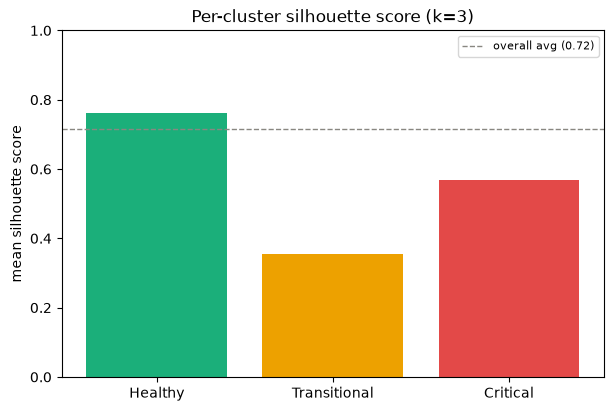

In [9]:
from sklearn.metrics import silhouette_samples
sil_samples = silhouette_samples(X[sample], labels[sample])
import pandas as pd
d = pd.DataFrame({'cluster': labels[sample], 'sil': sil_samples})
label_map = {0:'Healthy', 2:'Transitional', 1:'Critical'}
d['stage'] = d['cluster'].map(label_map)

fig, ax = plt.subplots(figsize=(7,4.5))
means = d.groupby('stage')['sil'].mean().reindex(['Healthy','Transitional','Critical'])
ax.bar(means.index, means.values, color=['#1baf7a','#eda100','#e34948'])
ax.axhline(sil_samples.mean(), color='#898781', linestyle='--', linewidth=1, label=f'overall avg ({sil_samples.mean():.2f})')
ax.set_ylabel('mean silhouette score'); ax.set_ylim(0,1)
ax.set_title('Per-cluster silhouette score (k=3)')
ax.legend(fontsize=8)
plt.show()

Healthy is well-separated (0.76). Transitional is noticeably weaker (0.35) which is expected as it sits in the middle space and boundary between critical and healthy. Critical (0.57) is solid despite being the smallest cluster. A low-but-positive score for a genuinely "in-between" stage is normal and this hence allows us to use k=3 reliably even though k=2 would have been better in theory.

## 5. Summary

- Both unsupervised components needed real debugging before they worked correctly -- raw features caused protocol-driven false patterns in both the anomaly detector and clustering, fixed the same way in both cases: restrict to ratio-normalized degradation signals only.
- Anomaly detector: 100% known-glitch catch rate, 4.2% false-positive rate, but structurally blind to capacity-based anomalies (separate mechanism handles those).
- Clustering: genuine 3-stage gradient, validated against real SOH/replacement data despite never using those labels for fitting.
- This completes the 5-component pipeline notebook series. Next: the agent layer that ties all 5 together.